In [152]:
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.interpolate import PchipInterpolator
from scipy.spatial.distance import pdist, squareform

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns


In [153]:
INSTALLED_CAPACITY_MW: float = 90.09
TURBINES_TOTAL: int = 26

CUT_IN_SPEED: float = 3.0
RATED_SPEED: float = 12.0
CUT_OUT_SPEED: float = 25.0

AIR_DENSITY_REF: float = 1.225
EPS: float = 1e-6

In [154]:
RANDOM_STATE: int = 42

In [155]:
ROOT_DIR: Path = Path.cwd().parent
DATA_DIR: Path = ROOT_DIR / Path("data")
MAP_DIR: Path = DATA_DIR / "map"
OUT_DIR: Path = ROOT_DIR / Path("outputs")

print(f"{ROOT_DIR=}")
print(f"{DATA_DIR=}")
print(f"{MAP_DIR=}")
print(f"{OUT_DIR=}")

ROOT_DIR=WindowsPath('f:/PycharmProjects/hackaton_ves_refactored')
DATA_DIR=WindowsPath('f:/PycharmProjects/hackaton_ves_refactored/data')
MAP_DIR=WindowsPath('f:/PycharmProjects/hackaton_ves_refactored/data/map')
OUT_DIR=WindowsPath('f:/PycharmProjects/hackaton_ves_refactored/outputs')


In [156]:
# train_merged.csv получено с Метеоданными от НАСА
# train.csv изначальные данные
TRAIN_CANDIDATES: list[Path] = [
    DATA_DIR / "train" / "train.csv",
    DATA_DIR / "train" / "train_merged.csv",
]

# valid_merged.csv получено с Метеоданными от НАСА
# valid.csv изначальные данные
VALID_CANDIDATES: list[Path] = [
    DATA_DIR / "valid" /"valid.csv",
    DATA_DIR / "valid" /"valid_merged.csv",
]

# test_merged.csv получено с Метеоданными от НАСА
# test.csv изначальные данные
TEST_CANDIDATES: list[Path] = [
    DATA_DIR / "test" /"test.csv",
    DATA_DIR / "test" /"test_merged.csv",
]

In [157]:
TRAIN_PATH: Path = [path for path in TRAIN_CANDIDATES if path.exists()][-1]

VALID_PATH: Path = [path for path in VALID_CANDIDATES if path.exists()][-1]

TEST_PATH: Path = [path for path in TEST_CANDIDATES if path.exists()][-1]

TURBINE_COORDS_PATH: Path = MAP_DIR / "wind_farm_coords.csv"

print(f"{TRAIN_PATH=}")
print(f"{VALID_PATH=}")
print(f"{TEST_PATH=}")

TRAIN_PATH=WindowsPath('f:/PycharmProjects/hackaton_ves_refactored/data/train/train_merged.csv')
VALID_PATH=WindowsPath('f:/PycharmProjects/hackaton_ves_refactored/data/valid/valid_merged.csv')
TEST_PATH=WindowsPath('f:/PycharmProjects/hackaton_ves_refactored/data/test/test_merged.csv')


In [158]:
TARGET_NAME: str = "Выработка. Результирующий расчет"
DATETIME_NAME: str = "METEOFORECASTHOUR_OPENM_Datetime"
REPAIR_NAME: str = "Кол-во_ВЭУ_в_ремонте"

In [159]:
df_train_raw: pd.DataFrame = pd.read_csv(TRAIN_PATH, parse_dates=[DATETIME_NAME])
df_valid_raw: pd.DataFrame = pd.read_csv(VALID_PATH, parse_dates=[DATETIME_NAME])
df_test_raw: pd.DataFrame = pd.read_csv(TEST_PATH, parse_dates=[DATETIME_NAME])

In [160]:
df_train_raw.head(2)

,METEOFORECASTHOUR_OPENM_Datetime,month,hour_of_day,Выработка. Результирующий расчет,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,...,T2MDEW,T2M,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC
0,2025-12-31 23:00:00,12,23,60.986,4.40,7.22,8.04,8.44,0.273,0.275,...,-8.25,-3.87,1.97,100.46,6.31,262.4,8.96,262.6,-6.06,12.41
1,2025-12-31 22:00:00,12,22,70.469,5.49,8.26,8.88,9.08,0.280,0.281,...,-8.36,-3.83,1.95,100.41,6.35,267.9,8.94,268.0,-6.10,12.38


In [161]:
# Сортируем 

df_train_raw.sort_values(by=DATETIME_NAME, ascending=True, inplace=True)
df_valid_raw.sort_values(by=DATETIME_NAME, ascending=True, inplace=True)
df_test_raw.sort_values(by=DATETIME_NAME, ascending=True, inplace=True)

df_train_raw.reset_index(drop=True, inplace=True)
df_valid_raw.reset_index(drop=True, inplace=True)
df_test_raw.reset_index(drop=True, inplace=True)

In [162]:
df_train_raw.head(2)

,METEOFORECASTHOUR_OPENM_Datetime,month,hour_of_day,Выработка. Результирующий расчет,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,...,T2MDEW,T2M,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC
0,2022-01-01 00:00:00,1,0,0.697,2.77,4.27,4.62,NaN,0.244,0.249,...,-3.12,-1.36,2.98,101.36,1.7,272.4,2.07,271.9,-2.24,2.87
1,2022-01-01 01:00:00,1,1,4.413,2.91,4.40,4.78,NaN,0.243,0.249,...,-3.10,-1.34,2.99,101.32,2.1,259.0,2.59,258.6,-2.22,3.59


In [163]:
df_train = df_train_raw.rename(columns={DATETIME_NAME: "datetime", TARGET_NAME: "target", REPAIR_NAME: "turbines_in_repair"}).copy()
df_valid = df_valid_raw.rename(columns={DATETIME_NAME: "datetime", TARGET_NAME: "target", REPAIR_NAME: "turbines_in_repair"}).copy()
df_test = df_test_raw.rename(columns={DATETIME_NAME: "datetime", TARGET_NAME: "target", REPAIR_NAME: "turbines_in_repair"}).copy()

for frame in [df_train, df_valid, df_test]:
    frame["datetime"] = pd.to_datetime(frame["datetime"], format="mixed").dt.round("h")

df_train = pd.concat([df_train, df_valid], ignore_index=True, sort=False)

In [164]:
df_train.describe() #Данные ненормализованы

,datetime,month,hour_of_day,target,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,...,T2MDEW,T2M,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC
count,34560,34560.000000,34560.000000,32434.000000,34560.000000,34560.000000,34560.000000,27724.000000,34560.000000,34560.000000,...,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000,34560.000000
mean,2024-02-24 02:21:43.958333,6.251071,11.527488,33.005746,4.234535,6.567428,7.457833,8.264885,0.165046,0.166648,...,6.380777,11.823354,6.658932,101.407412,5.393908,166.473547,7.080535,166.853898,9.102067,9.807349
min,2022-01-01 00:00:00,1.000000,0.000000,0.001000,0.100000,0.000000,0.100000,0.100000,0.001000,0.001000,...,-13.710000,-14.180000,1.190000,98.260000,0.060000,0.000000,0.020000,0.000000,-13.950000,0.030000
25%,2023-02-04 01:45:00,3.000000,6.000000,8.838750,2.690000,4.400000,4.920000,5.020000,0.074000,0.077000,...,0.390000,2.730000,3.860000,100.890000,3.620000,79.700000,4.930000,80.575000,1.627500,6.830000
50%,2024-02-26 16:30:00,6.000000,12.000000,27.124500,3.930000,6.330000,7.180000,7.780000,0.151000,0.150000,...,6.750000,10.800000,6.060000,101.340000,5.090000,135.650000,6.950000,136.100000,8.905000,9.630000
75%,2025-03-15 05:15:00,9.000000,18.000000,56.943250,5.520000,8.390000,9.750000,11.080000,0.255000,0.257000,...,12.520000,20.860000,8.990000,101.900000,6.900000,258.100000,9.000000,258.500000,16.950000,12.470000
max,2026-03-31 23:00:00,12.000000,23.000000,87.475000,14.910000,20.610000,21.990000,25.110000,0.360000,0.360000,...,23.390000,37.740000,18.050000,103.990000,18.700000,359.900000,23.350000,359.900000,27.490000,32.340000
std,NaN,3.553335,6.931389,26.121408,2.112980,2.910947,3.348755,4.100655,0.102150,0.101551,...,7.654787,10.587933,3.353827,0.763926,2.458983,101.556020,3.025947,101.398420,8.932831,4.191266


In [165]:
df_train.info() # Есть пропущенные значения

<class 'pandas.DataFrame'>
RangeIndex: 34560 entries, 0 to 34559
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datetime             34560 non-null  datetime64[us]
 1   month                34560 non-null  int64         
 2   hour_of_day          34560 non-null  int64         
 3   target               32434 non-null  float64       
 4   wind_speed_10m       34560 non-null  float64       
 5   wind_speed_80m       34560 non-null  float64       
 6   wind_speed_120m      34560 non-null  float64       
 7   wind_speed_180m      27724 non-null  float64       
 8   wind_direction_10m   34560 non-null  float64       
 9   wind_direction_80m   34560 non-null  float64       
 10  wind_direction_120m  34560 non-null  float64       
 11  wind_direction_180m  27724 non-null  float64       
 12  wind_gusts_10m       34560 non-null  float64       
 13  temperature_80m      34560 non-null  float

In [166]:
df_train.isna().sum()[df_train.isna().sum() > 0]

target                 2126
wind_speed_180m        6836
wind_direction_180m    6836
dtype: int64

In [167]:
SPEED_COLS: list[str] = [
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
]

DIRECTION_COLS: list[str] = [
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
]

HEIGHT_PAIRS: list[tuple[int]] = [
    (10, 80),
    (80, 120),
    (120, 180),
    (80, 180),
    (10, 120),
]

In [168]:
df_train["source"] = "train"
df_test["source"] = "test"

df_full = pd.concat([df_train, df_test], ignore_index=True, sort=False)
df_full.head(2)

,datetime,month,hour_of_day,target,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,...,T2M,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC,source
0,2022-01-01 00:00:00,1,0,0.697,2.77,4.27,4.62,NaN,0.244,0.249,...,-1.36,2.98,101.36,1.7,272.4,2.07,271.9,-2.24,2.87,train
1,2022-01-01 01:00:00,1,1,4.413,2.91,4.40,4.78,NaN,0.243,0.249,...,-1.34,2.99,101.32,2.1,259.0,2.59,258.6,-2.22,3.59,train


In [169]:
df_full["month"] = df_full["datetime"].dt.month
df_full["hour_of_day"] = df_full["datetime"].dt.hour
df_full["dayofyear"] = df_full["datetime"].dt.dayofyear
df_full["dayofweek"] = df_full["datetime"].dt.dayofweek

# Синусы и косинусы для понятия цикличности
df_full["hour_sin"] = np.sin(2 * np.pi * df_full["hour_of_day"] / 24)
df_full["hour_cos"] = np.cos(2 * np.pi * df_full["hour_of_day"] / 24)

df_full["month_sin"] = np.sin(2 * np.pi * df_full["month"] / 12)
df_full["month_cos"] = np.cos(2 * np.pi * df_full["month"] / 12)

df_full["dayofyear_sin"] = np.sin(2 * np.pi * df_full["dayofyear"] / 366)
df_full["dayofyear_cos"] = np.cos(2 * np.pi * df_full["dayofyear"] / 366)

In [170]:
for col in SPEED_COLS:
    df_full[f"{col}_sq"] = df_full[f"{col}"] ** 2
    df_full[f"{col}_cube"] = df_full[f"{col}"] ** 3
    print(f"Добавлены доп. фичи для: {col}")

print()

for col in DIRECTION_COLS:
    angle = np.deg2rad(df_full[col] * 1000)
    feature_prefix = col.replace("wind_direction", "wind_dir")
    df_full[f"{feature_prefix}_sin"] = np.sin(angle)
    df_full[f"{feature_prefix}_cos"] = np.cos(angle)

    print(f"Добавлены доп. фичи для: {col}")

Добавлены доп. фичи для: wind_speed_10m
Добавлены доп. фичи для: wind_speed_80m
Добавлены доп. фичи для: wind_speed_120m
Добавлены доп. фичи для: wind_speed_180m

Добавлены доп. фичи для: wind_direction_10m
Добавлены доп. фичи для: wind_direction_80m
Добавлены доп. фичи для: wind_direction_120m
Добавлены доп. фичи для: wind_direction_180m


In [171]:
# Разницы и отношение между соседними высотами

df_full["ws_120_cube"] = df_full["wind_speed_120m"] ** 3
df_full["ws_diff_120_80"] = df_full["wind_speed_120m"] - df_full["wind_speed_80m"]
df_full["ws_ratio_120_80"] = df_full["wind_speed_120m"] / (df_full["wind_speed_80m"] + EPS)

df_full["ws_diff_180_120"] = df_full["wind_speed_180m"] - df_full["wind_speed_120m"]

df_full["gust_ratio_10m"] = df_full["wind_gusts_10m"] / (df_full["wind_speed_10m"] + EPS)

In [172]:
# Плотность воздуха
temperature_mean = 0.5 * (df_full["temperature_80m"] + df_full["temperature_120m"])
temperature_mean_k = temperature_mean + 273.15

pressure_pa = df_full["pressure_msl"] * 100

df_full["air_density"] = pressure_pa / (287.05 * temperature_mean_k)
df_full["density_ratio"] = (df_full["air_density"] / AIR_DENSITY_REF).clip(0.75, 1.30)


In [173]:
for height in (80, 120):
    speed_col: str = f"wind_speed_{height}m"

    # P ~ pV**3, P - мощность, p - тек. плотность, V - тек. скорость
    # p0 * V_corrected ** 3 = pV**3, p0 - станд. плотность, V_corrected - скомп. скорость ->
    # V_corrected = V * (p/p0) ** (1/3)
    df_full[f"wind_speed_{height}m_density_corrected"] = (df_full[speed_col] * (df_full["density_ratio"] ** (1 / 3)))


    # P/A = 1/2 * pV**3, P - мощность, A - площадь, через которую проходит воздух, p - полотность, V - скорость ветра
    df_full[f"wind_power_density_{height}m"] = (0.5 * df_full["air_density"] * df_full[speed_col] ** 3)


In [174]:
for col in df_full.columns:
    df_full[col] = df_full[col].replace([np.inf, -np.inf], np.nan)

In [175]:
# Доступная мощность
availability = (TURBINES_TOTAL - df_full["turbines_in_repair"]).clip(0, TURBINES_TOTAL) / TURBINES_TOTAL

df_full["available_capacity_mw"] = availability * INSTALLED_CAPACITY_MW

In [176]:
for height in [80, 120]:
    speed_col: str = f"wind_speed_{height}m"

    speed = df_full[speed_col].clip(lower=0)

    # Кубическая зависимость между скоростью запуска и номинальной скоростью
    numer = (speed ** 3 - CUT_IN_SPEED ** 3)
    denom = (RATED_SPEED ** 3 - CUT_IN_SPEED ** 3)
    curve =  (numer / denom).clip(0, 1)

    curve = curve.where(speed >= CUT_IN_SPEED, 0)
    curve = curve.where(speed < CUT_OUT_SPEED, 0)

    # Теоритическая мощность на основе физики
    df_full[f"p_theory_{height}"] = INSTALLED_CAPACITY_MW * curve * availability

df_full["p_theory_mean_80_120"] = 0.5 * (df_full["p_theory_80"] + df_full["p_theory_120"])

In [177]:
def add_shear_feature(df: pd.DataFrame, low_h: float, high_h: float) -> None:
    low_col_speed: str = f"wind_speed_{low_h}m"
    high_col_speed: str = f"wind_speed_{high_h}m"
    out_col = f"shear_{low_h}_{high_h}"

    # коэффицент вертикального сдвига между low_h и high_h
    # коэф = ln(v2/v1) / ln(h2/h1)

    numer = np.log((df[high_col_speed].clip(lower=EPS)) / (df[low_col_speed].clip(lower=EPS)))
    denom = np.log(high_h / low_h)

    df[out_col] = numer / denom
    df[out_col] = df[out_col].replace([np.inf, -np.inf], np.nan)


for low_h, high_h in HEIGHT_PAIRS:
    add_shear_feature(df_full, low_h, high_h)

In [178]:
CAP_SPEED_HEIGHT: int = 120
CAP_SPEED_VALUE: int = 13

cap_col = f"wind_speed_{CAP_SPEED_HEIGHT}m"
if cap_col in df_full.columns:
    base = f"wind{CAP_SPEED_HEIGHT}_cap{CAP_SPEED_VALUE}"

df_full["wind120_cap13_above"] = (df_full["wind_speed_120m"] - 13).clip(lower=0)
df_full["wind120_cap13_clipped"] = df_full["wind_speed_120m"].clip(upper=13)
df_full["wind120_cap13_is_above"] = (df_full["wind_speed_120m"] > 13).astype(int)
df_full["wind120_cap13_clipped_cube"] = df_full["wind120_cap13_clipped"] ** 3

In [179]:
# Направление ветра по секторам

DIRECTION_SECTOR_HEIGHTS: list[int] = [80, 120, 180]
DIRECTION_SECTOR_COUNTS: list[int] = [8, 16]

for height in DIRECTION_SECTOR_HEIGHTS:
    col = f"wind_direction_{height}m"

    deg = (df_full[col] * 1000) % 360

    for n_sec in DIRECTION_SECTOR_COUNTS:
            sec_col = f"wind_dir_{height}m_sector_{n_sec}"

            sector = np.floor(deg / (360 / n_sec))
            sector = sector.replace([np.inf, -np.inf], np.nan).fillna(-1).clip(-1, n_sec - 1).astype(int)

            df_full[sec_col] = sector

In [180]:
# Соглосованность метеоданных

meteo_cols: list[tuple[str]] = [
    ("wind_speed_10m", "WS10M", "ws10_openm_minus_nasa"),
    ("wind_speed_80m", "WS50M", "ws80_openm_minus_nasa50"),
    ("pressure_msl", "PS", "pressure_msl_minus_ps"),
    ("temperature_80m", "T2M", "temp80_minus_t2m"),
    ]

for openm_col, nasa_col, new_col in meteo_cols:
    df_full[new_col] = df_full[openm_col] - df_full[nasa_col]
    df_full[new_col] = df_full[new_col].replace([np.inf, -np.inf], np.nan)

openm_deg = (df_full["wind_direction_10m"] * 1000) % 360
nasa_deg = df_full["WD10M"] % 360

diff = ((openm_deg - nasa_deg + 180) % 360) - 180
df_full["wd10_openm_minus_nasa_circular"] = diff.replace([np.inf, -np.inf], np.nan)

In [181]:
EWM_SPANS: dict[str: int] = {
    "3h": 3,
    "5h": 5,
    "7h": 7
}

EMA_SOURCE_COLS: list[str] = [
    "wind_speed_120m_cube",
    "p_theory_80",
    "p_theory_120",
    "wind_power_density_120m",
]

NWP_SHIFTS: list[int] = [-6, -3, -2, -1, 1, 2, 3, 6]

NWP_BASE_COLS: list[str] = [
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_120m_cube",
    "wind_speed_120m_density_corrected",
    "p_theory_120",
    "wind_power_density_120m",
]

In [182]:
df_full["datetime"] = pd.to_datetime(df_full["datetime"], errors="coerce")

# Глобальная сортировка
df_full = (df_full.sort_values("datetime").reset_index(drop=True))

assert df_full["datetime"].is_monotonic_increasing


time_features = {}

for col in EMA_SOURCE_COLS:
    if col not in df_full.columns:
        continue

    for window_str, span_val in EWM_SPANS.items():
        time_features[f"{col}_smooth_{window_str}"] = df_full[col].ewm(span=span_val, min_periods=1).mean()

    time_features[f"{col}_minus_smooth_3h"] = df_full[col] - time_features[f"{col}_smooth_3h"]


# Индекс для точного поиска по времени
time_indexed = df_full.set_index("datetime")

for col in NWP_BASE_COLS:
    if col not in time_indexed.columns:
        continue

    for shift_hours in NWP_SHIFTS:
        shifted_datetime = df_full["datetime"] + pd.to_timedelta(shift_hours, unit="h")

        label = f"plus_{shift_hours}h" if shift_hours > 0 else f"minus_{abs(shift_hours)}h"
        

        time_features[f"{col}_nwp_{label}"] = time_indexed[col].reindex(shifted_datetime).to_numpy()

df_full = pd.concat([df_full, pd.DataFrame(time_features, index=df_full.index)], axis=1)

ema_effect_rows = []

for col in EMA_SOURCE_COLS:
    raw = pd.to_numeric(df_full[col], errors="coerce")
    smooth = pd.to_numeric(df_full[f"{col}_smooth_3h"], errors="coerce")
    delta = pd.to_numeric(df_full[f"{col}_minus_smooth_3h"], errors="coerce")

    ema_effect_rows.append({
        "signal": col,
        "raw_std": raw.std(),
        "smooth_3h_std": smooth.std(),
        "raw_minus_smooth_3h_std": delta.std(),
        "raw_missing_share": raw.isna().mean(),
    })

ema_effect_df = pd.DataFrame(ema_effect_rows)
ema_effect_df

,signal,raw_std,smooth_3h_std,raw_minus_smooth_3h_std,raw_missing_share
0,wind_speed_120m_cube,855.775117,828.377601,151.885922,0.0
1,p_theory_80,20.510568,19.941938,3.391179,0.0
2,p_theory_120,25.284255,24.509977,4.390326,0.0
3,wind_power_density_120m,539.023733,522.232764,94.388344,0.0


In [183]:
EMPIRICAL_SPEED_HEIGHTS: list[int] = [80, 120]
EMPIRICAL_SPEED_BINS: np.array = np.arange(0, 26.5, 0.5)
EMPIRICAL_MIN_BIN_COUNT: int = 20
EMPIRICAL_CF_MAX: float = 1.15

In [184]:
df_train = (df_full[df_full["source"].eq("train")].copy().sort_values("datetime").reset_index(drop=True)
)

df_test = (df_full[df_full["source"].eq("test")].copy().sort_values("datetime").reset_index(drop=True)
)

df_train.drop(columns="source", inplace=True)
df_test.drop(columns="source", inplace=True)

In [185]:
def add_empirical_power_features(df_features: pd.DataFrame, df_reference: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    df_result = df_features.copy()
    df_reference = df_reference.copy()

    # Коэффициент использования доступной мощности:
    # CF = фактическая мощность / доступная мощность
    available_capacity = df_reference["available_capacity_mw"].clip(lower=1.0)
    df_reference["actual_capacity_factor"] = (df_reference["target"] / available_capacity).clip(0, EMPIRICAL_CF_MAX)

    isotonic_feature_cols = []

    for height in EMPIRICAL_SPEED_HEIGHTS:
        speed_col = f"wind_speed_{height}m_density_corrected"

        df_curve = df_reference[[speed_col, "actual_capacity_factor"]].dropna().copy()

        # Разделяем скорость ветра на интервалы по 0.5 м/с
        df_curve["speed_bin"] = pd.cut(df_curve[speed_col], bins=EMPIRICAL_SPEED_BINS, labels=False)

        # Для каждого интервала считаем медианный CF и количество наблюдений
        df_curve = df_curve.groupby("speed_bin", as_index=False).agg(
            median_capacity_factor=("actual_capacity_factor", "median"),
            observations_count=("actual_capacity_factor", "size")
        )

        # Оставляем интервалы с достаточным количеством наблюдений
        df_curve = df_curve[df_curve["observations_count"] >= EMPIRICAL_MIN_BIN_COUNT].copy()

        # Берем середину каждого интервала скорости
        df_curve["wind_speed"] = EMPIRICAL_SPEED_BINS[df_curve["speed_bin"].astype(int)] + 0.25
        df_curve.sort_values("wind_speed", inplace=True)

        # Делаем коэффициент мощности неубывающим при росте скорости
        monotonic_capacity_factor = np.maximum.accumulate(df_curve["median_capacity_factor"].to_numpy())

        # Добавляем начальную и конечную точки кривой
        curve_speed = np.r_[0.0, df_curve["wind_speed"].to_numpy(), CUT_OUT_SPEED]
        curve_capacity_factor = np.r_[0.0, monotonic_capacity_factor, monotonic_capacity_factor[-1]]

        # Удаляем повторяющиеся значения скорости
        curve_speed, unique_indexes = np.unique(curve_speed, return_index=True)
        curve_capacity_factor = curve_capacity_factor[unique_indexes]

        # Строим плавную эмпирическую кривую мощности
        power_curve = PchipInterpolator(curve_speed, curve_capacity_factor, extrapolate=True)

        wind_speed = df_result[speed_col].clip(0, CUT_OUT_SPEED)

        # Получаем CF по эмпирической кривой
        empirical_capacity_factor = np.clip(power_curve(wind_speed), 0, EMPIRICAL_CF_MAX)

        # Ниже скорости запуска и выше скорости отключения мощность равна нулю
        empirical_capacity_factor = np.where(df_result[speed_col] < CUT_IN_SPEED, 0, empirical_capacity_factor)
        empirical_capacity_factor = np.where(df_result[speed_col] >= CUT_OUT_SPEED, 0, empirical_capacity_factor)

        # P = CF * доступная мощность
        df_result[f"p_empirical_{height}"] = empirical_capacity_factor * df_result["available_capacity_mw"]
        df_result[f"cf_empirical_{height}"] = empirical_capacity_factor

        # Строим вторую монотонную кривую через изотоническую регрессию
        isotonic_model = IsotonicRegression(y_min=0.0, y_max=EMPIRICAL_CF_MAX, increasing=True, out_of_bounds="clip")
        isotonic_model.fit(df_curve["wind_speed"], df_curve["median_capacity_factor"])

        isotonic_capacity_factor = np.clip(isotonic_model.predict(wind_speed), 0, EMPIRICAL_CF_MAX)

        # Ниже скорости запуска и выше скорости отключения мощность равна нулю
        isotonic_capacity_factor = np.where(df_result[speed_col] < CUT_IN_SPEED, 0, isotonic_capacity_factor)
        isotonic_capacity_factor = np.where(df_result[speed_col] >= CUT_OUT_SPEED, 0, isotonic_capacity_factor)

        # P = CF * доступная мощность
        df_result[f"p_empirical_iso_{height}"] = isotonic_capacity_factor * df_result["available_capacity_mw"]
        df_result[f"cf_empirical_iso_{height}"] = isotonic_capacity_factor

        isotonic_feature_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]

    # Средняя эмпирическая мощность по скоростям на 80 и 120 метрах
    df_result["p_empirical_mean_80_120"] = 0.5 * (df_result["p_empirical_80"] + df_result["p_empirical_120"])

    # Средняя изотоническая мощность по скоростям на 80 и 120 метрах
    df_result["p_empirical_iso_mean_80_120"] = 0.5 * (df_result["p_empirical_iso_80"] + df_result["p_empirical_iso_120"])

    # Разница между эмпирической и теоретической мощностью
    df_result["p_empirical_minus_theory_120"] = df_result["p_empirical_120"] - df_result["p_theory_120"]

    isotonic_feature_cols.append("p_empirical_iso_mean_80_120")

    return df_result, isotonic_feature_cols

In [186]:
df_train, isotonic_train_cols = add_empirical_power_features(df_train, df_train)
df_test, isotonic_test_cols = add_empirical_power_features(df_test, df_train)

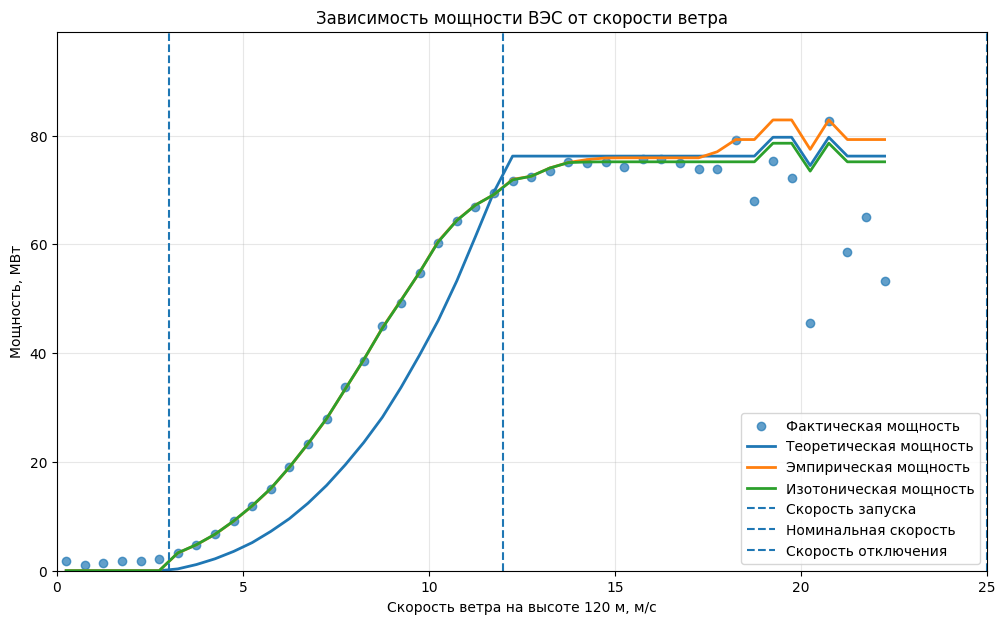

In [187]:
# График фактической, теоретической и эмпирической мощности

df_power_curve = df_train[["wind_speed_120m_density_corrected", "target", "p_theory_120", "p_empirical_120", "p_empirical_iso_120"]].dropna().copy()

# Разделяем скорость на интервалы по 0.5 м/с
df_power_curve["speed_bin"] = pd.cut(df_power_curve["wind_speed_120m_density_corrected"], bins=EMPIRICAL_SPEED_BINS, labels=False)

# Для каждого интервала считаем медианное значение мощности
df_power_curve = df_power_curve.groupby("speed_bin", as_index=False).agg(actual_power=("target", "median"), theoretical_power=("p_theory_120", "median"), empirical_power=("p_empirical_120", "median"), isotonic_power=("p_empirical_iso_120", "median"))

# Берем середину каждого интервала скорости
df_power_curve["wind_speed"] = EMPIRICAL_SPEED_BINS[df_power_curve["speed_bin"].astype(int)] + 0.25
df_power_curve.sort_values("wind_speed", inplace=True)

plt.figure(figsize=(12, 7))

plt.scatter(df_power_curve["wind_speed"], df_power_curve["actual_power"], label="Фактическая мощность", alpha=0.7)
plt.plot(df_power_curve["wind_speed"], df_power_curve["theoretical_power"], label="Теоретическая мощность", linewidth=2)
plt.plot(df_power_curve["wind_speed"], df_power_curve["empirical_power"], label="Эмпирическая мощность", linewidth=2)
plt.plot(df_power_curve["wind_speed"], df_power_curve["isotonic_power"], label="Изотоническая мощность", linewidth=2)

plt.axvline(CUT_IN_SPEED, linestyle="--", label="Скорость запуска")
plt.axvline(RATED_SPEED, linestyle="--", label="Номинальная скорость")
plt.axvline(CUT_OUT_SPEED, linestyle="--", label="Скорость отключения")

plt.xlabel("Скорость ветра на высоте 120 м, м/с")
plt.ylabel("Мощность, МВт")
plt.title("Зависимость мощности ВЭС от скорости ветра")
plt.xlim(0, CUT_OUT_SPEED)
plt.ylim(0, INSTALLED_CAPACITY_MW * 1.1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [188]:
# Берем все готовые числовые признаки, которые есть и в train, и в test

MODEL_FEATURE_CONTRACT = [
    "month", "hour_of_day", "wind_speed_10m", "wind_speed_80m", "wind_speed_120m",
    "wind_speed_180m", "wind_direction_10m", "wind_direction_80m", "wind_direction_120m",
    "wind_direction_180m", "wind_gusts_10m", "temperature_80m", "temperature_120m",
    "pressure_msl", "rain", "showers", "snowfall", "cloud_cover_low", "turbines_in_repair",
    "available_capacity_mw", "air_density", "density_ratio", "wind_power_density_80m",
    "wind_power_density_120m", "p_theory_80", "p_theory_120", "p_theory_mean_80_120",
    "p_empirical_80", "p_empirical_120", "p_empirical_mean_80_120",
    "p_empirical_minus_theory_120", "cf_empirical_80", "cf_empirical_120",
    "dayofyear_sin", "dayofyear_cos",
    "wind_speed_10m_sq", "wind_speed_10m_cube", "wind_speed_80m_sq", "wind_speed_80m_cube",
    "wind_speed_120m_sq", "wind_speed_120m_cube", "wind_speed_180m_sq", "wind_speed_180m_cube",
    "wind_dir_10m_sin", "wind_dir_10m_cos", "wind_dir_80m_sin", "wind_dir_80m_cos",
    "wind_dir_120m_sin", "wind_dir_120m_cos", "wind_dir_180m_sin", "wind_dir_180m_cos",
    "ws_120_cube", "ws_diff_120_80", "ws_ratio_120_80", "ws_diff_180_120", "gust_ratio_10m",
    "wind_speed_80m_density_corrected", "wind_speed_120m_density_corrected",
    "wind120_cap13_clipped_cube", "wind_dir_80m_sector_8", "wind_dir_80m_sector_16",
    "wind_dir_120m_sector_8", "wind_dir_120m_sector_16", "wind_dir_180m_sector_8",
    "wind_dir_180m_sector_16",
    "wind_speed_120m_cube_smooth_3h", "wind_speed_120m_cube_smooth_5h",
    "wind_speed_120m_cube_smooth_7h", "wind_speed_120m_cube_minus_smooth_3h",
    "p_theory_80_smooth_3h", "p_theory_80_smooth_5h", "p_theory_80_smooth_7h",
    "p_theory_80_minus_smooth_3h", "p_theory_120_smooth_3h", "p_theory_120_smooth_5h",
    "p_theory_120_smooth_7h", "p_theory_120_minus_smooth_3h",
    "wind_power_density_120m_smooth_3h", "wind_power_density_120m_smooth_5h",
    "wind_power_density_120m_smooth_7h", "wind_power_density_120m_minus_smooth_3h",
    "wind_speed_80m_nwp_minus_6h", "wind_speed_80m_nwp_minus_3h",
    "wind_speed_80m_nwp_minus_2h", "wind_speed_80m_nwp_minus_1h",
    "wind_speed_80m_nwp_plus_1h", "wind_speed_80m_nwp_plus_2h",
    "wind_speed_80m_nwp_plus_3h", "wind_speed_80m_nwp_plus_6h",
    "wind_speed_120m_nwp_minus_6h", "wind_speed_120m_nwp_minus_3h",
    "wind_speed_120m_nwp_minus_2h", "wind_speed_120m_nwp_minus_1h",
    "wind_speed_120m_nwp_plus_1h", "wind_speed_120m_nwp_plus_2h",
    "wind_speed_120m_nwp_plus_3h", "wind_speed_120m_nwp_plus_6h",
    "wind_speed_120m_cube_nwp_minus_6h", "wind_speed_120m_cube_nwp_minus_3h",
    "wind_speed_120m_cube_nwp_minus_2h", "wind_speed_120m_cube_nwp_minus_1h",
    "wind_speed_120m_cube_nwp_plus_1h", "wind_speed_120m_cube_nwp_plus_2h",
    "wind_speed_120m_cube_nwp_plus_3h", "wind_speed_120m_cube_nwp_plus_6h",
    "wind_speed_120m_density_corrected_nwp_minus_6h",
    "wind_speed_120m_density_corrected_nwp_minus_3h",
    "wind_speed_120m_density_corrected_nwp_minus_2h",
    "wind_speed_120m_density_corrected_nwp_minus_1h",
    "wind_speed_120m_density_corrected_nwp_plus_1h",
    "wind_speed_120m_density_corrected_nwp_plus_2h",
    "wind_speed_120m_density_corrected_nwp_plus_3h",
    "wind_speed_120m_density_corrected_nwp_plus_6h",
    "p_theory_120_nwp_minus_6h", "p_theory_120_nwp_minus_3h",
    "p_theory_120_nwp_minus_2h", "p_theory_120_nwp_minus_1h",
    "p_theory_120_nwp_plus_1h", "p_theory_120_nwp_plus_2h",
    "p_theory_120_nwp_plus_3h", "p_theory_120_nwp_plus_6h",
    "wind_power_density_120m_nwp_minus_6h", "wind_power_density_120m_nwp_minus_3h",
    "wind_power_density_120m_nwp_minus_2h", "wind_power_density_120m_nwp_minus_1h",
    "wind_power_density_120m_nwp_plus_1h", "wind_power_density_120m_nwp_plus_2h",
    "wind_power_density_120m_nwp_plus_3h", "wind_power_density_120m_nwp_plus_6h",
    "shear_10_120", "shear_10_80", "shear_120_180", "shear_80_120", "shear_80_180",
    "wind120_cap13_above", "wind120_cap13_clipped", "wind120_cap13_is_above",
    "pressure_msl_minus_ps", "temp80_minus_t2m", "wd10_openm_minus_nasa_circular",
    "ws10_openm_minus_nasa", "ws80_openm_minus_nasa50",
    "cf_empirical_iso_120", "cf_empirical_iso_80", "p_empirical_iso_120",
    "p_empirical_iso_80", "p_empirical_iso_mean_80_120",
]

model_features = MODEL_FEATURE_CONTRACT.copy()

print("Количество признаков:", len(model_features))
model_features

Количество признаков: 147


['month',
 'hour_of_day',
 'wind_speed_10m',
 'wind_speed_80m',
 'wind_speed_120m',
 'wind_speed_180m',
 'wind_direction_10m',
 'wind_direction_80m',
 'wind_direction_120m',
 'wind_direction_180m',
 'wind_gusts_10m',
 'temperature_80m',
 'temperature_120m',
 'pressure_msl',
 'rain',
 'showers',
 'snowfall',
 'cloud_cover_low',
 'turbines_in_repair',
 'available_capacity_mw',
 'air_density',
 'density_ratio',
 'wind_power_density_80m',
 'wind_power_density_120m',
 'p_theory_80',
 'p_theory_120',
 'p_theory_mean_80_120',
 'p_empirical_80',
 'p_empirical_120',
 'p_empirical_mean_80_120',
 'p_empirical_minus_theory_120',
 'cf_empirical_80',
 'cf_empirical_120',
 'dayofyear_sin',
 'dayofyear_cos',
 'wind_speed_10m_sq',
 'wind_speed_10m_cube',
 'wind_speed_80m_sq',
 'wind_speed_80m_cube',
 'wind_speed_120m_sq',
 'wind_speed_120m_cube',
 'wind_speed_180m_sq',
 'wind_speed_180m_cube',
 'wind_dir_10m_sin',
 'wind_dir_10m_cos',
 'wind_dir_80m_sin',
 'wind_dir_80m_cos',
 'wind_dir_120m_sin',
 'wi

In [189]:
# Расчёт затухания ветра 

N_LAYOUT_CLUSTERS = 4
LAYOUT_KMEANS_N_INIT = 30

WAKE_DIRECTION_STEP_DEG = 5
WAKE_LATERAL_THRESHOLD_M = 260
WAKE_MAX_DOWNWIND_M = 2500
WAKE_DECAY_DOWNWIND_M = 800

BEST_WAKE_FEATURE = "layout_wake_risk_scalar_120m"

In [190]:
print(f"{N_LAYOUT_CLUSTERS=}")
print(f"{WAKE_DIRECTION_STEP_DEG=}")
print(f"{BEST_WAKE_FEATURE=}")

N_LAYOUT_CLUSTERS=4
WAKE_DIRECTION_STEP_DEG=5
BEST_WAKE_FEATURE='layout_wake_risk_scalar_120m'


In [191]:
turbines = pd.read_csv(TURBINE_COORDS_PATH)
turbines.head(3)

,turbine_id,x,y,lat,lon
0,1,118.751948,36.124675,46.866668,38.686455
1,2,300.325974,34.223377,46.866857,38.701897
2,3,488.554545,61.792208,46.865322,38.718040


Турбин: 26
Среднее ближайшее расстояние: 343.0 м
Медианное ближайшее расстояние: 353.6 м
Главная ось ВЭС: 9.30 град. / 189.30 град.
Доля объяснённой дисперсии PCA: [0.69031765 0.30968235]


,cluster_id,cluster_axis_compass_deg,cluster_axis_evr,n
0,0,1.049124,0.999860,6
1,1,0.071119,0.999975,8
2,2,88.689012,0.831549,6
3,3,333.710799,0.965362,6


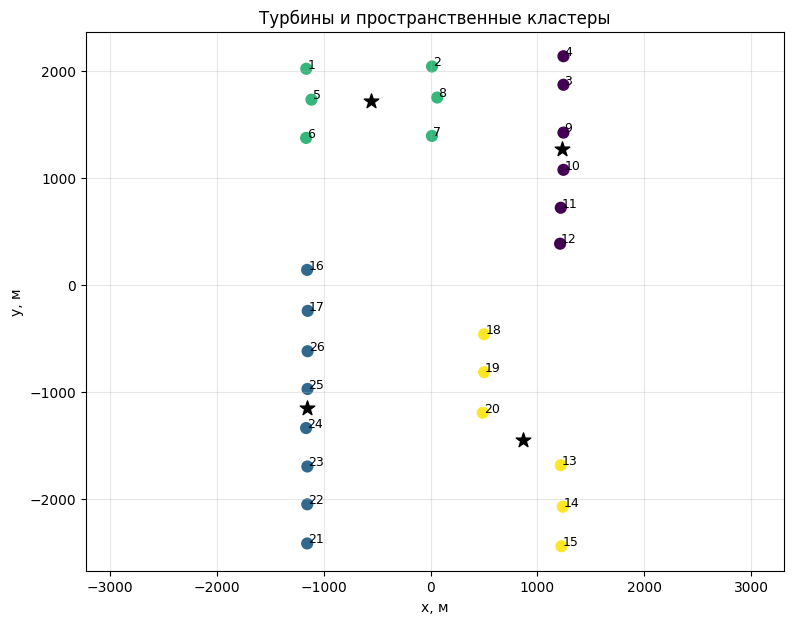

In [192]:
# Загружаем координаты турбин
turbines = pd.read_csv(TURBINE_COORDS_PATH)

# Координаты центра ВЭС
lat_center = turbines["lat"].mean()
lon_center = turbines["lon"].mean()

# Приближённый перевод широты и долготы в метры
meters_per_latitude_degree = 111_320
meters_per_longitude_degree = 111_320 * np.cos(np.deg2rad(lat_center))

turbines["x_m"] = (turbines["lon"] - lon_center) * meters_per_longitude_degree
turbines["y_m"] = (turbines["lat"] - lat_center) * meters_per_latitude_degree

coordinates = turbines[["x_m", "y_m"]].to_numpy()

# Матрица расстояний между всеми турбинами
distance_matrix = squareform(pdist(coordinates))

# Исключаем расстояние турбины до самой себя
np.fill_diagonal(distance_matrix, np.inf)

# Для каждой турбины находим расстояние до ближайшей соседней
nearest_distance = distance_matrix.min(axis=1)

print("Турбин:", len(turbines))
print(f"Среднее ближайшее расстояние: {nearest_distance.mean():.1f} м")
print(f"Медианное ближайшее расстояние: {np.median(nearest_distance):.1f} м")

# Разделяем турбины на пространственные кластеры
layout_model = KMeans(n_clusters=N_LAYOUT_CLUSTERS, random_state=RANDOM_STATE, n_init=LAYOUT_KMEANS_N_INIT)
turbines["layout_cluster"] = layout_model.fit_predict(coordinates)

# Находим основное направление всей ВЭС
farm_pca = PCA(n_components=2)
farm_pca.fit(coordinates)

main_axis = farm_pca.components_[0]
axis_angle = np.rad2deg(np.arctan2(main_axis[1], main_axis[0])) % 360
farm_axis = (90 - axis_angle) % 360

print(f"Главная ось ВЭС: {farm_axis:.2f} град. / {(farm_axis + 180) % 360:.2f} град.")
print("Доля объяснённой дисперсии PCA:", farm_pca.explained_variance_ratio_)

# Находим основное направление каждого кластера
cluster_axes = []

for cluster_id in sorted(turbines["layout_cluster"].unique()):
    cluster_coordinates = turbines.loc[turbines["layout_cluster"] == cluster_id, ["x_m", "y_m"]].to_numpy()

    if len(cluster_coordinates) >= 2:
        cluster_pca = PCA(n_components=2)
        cluster_pca.fit(cluster_coordinates)

        cluster_axis = cluster_pca.components_[0]
        cluster_angle = np.rad2deg(np.arctan2(cluster_axis[1], cluster_axis[0])) % 360
        cluster_compass_angle = (90 - cluster_angle) % 360
        explained_variance = cluster_pca.explained_variance_ratio_[0]
    else:
        cluster_compass_angle = np.nan
        explained_variance = np.nan

    cluster_axes.append({
        "cluster_id": cluster_id,
        "cluster_axis_compass_deg": cluster_compass_angle,
        "cluster_axis_evr": explained_variance,
        "n": len(cluster_coordinates)
    })

cluster_axis_df = pd.DataFrame(cluster_axes)
display(cluster_axis_df)

# Рисуем турбины и центры кластеров
plt.figure(figsize=(9, 7))
plt.scatter(turbines["x_m"], turbines["y_m"], c=turbines["layout_cluster"], s=60)
plt.scatter(layout_model.cluster_centers_[:, 0], layout_model.cluster_centers_[:, 1], c="black", marker="*", s=120)

for row in turbines.itertuples():
    plt.text(row.x_m + 10, row.y_m + 10, str(row.turbine_id), fontsize=9)

plt.axis("equal")
plt.grid(alpha=0.3)
plt.title("Турбины и пространственные кластеры")
plt.xlabel("x, м")
plt.ylabel("y, м")
plt.show()

In [193]:
def compute_wake_risk_for_direction(xy: np.ndarray, wind_from_deg: float, lateral_threshold_m: float = WAKE_LATERAL_THRESHOLD_M, max_downwind_m: float = WAKE_MAX_DOWNWIND_M, decay_downwind_m: float = WAKE_DECAY_DOWNWIND_M) -> tuple[int, float]:
    # Направление ветра задаётся как направление, откуда он дует. Разворачиваем его на 180°, чтобы получить направление движения воздушного потока и аэродинамического следа.
    flow_to_deg = (wind_from_deg + 180) % 360
    theta = np.deg2rad(flow_to_deg)
    flow_vector = np.array([np.sin(theta), np.cos(theta)])
    side_vector = np.array([np.cos(theta), -np.sin(theta)])

    pair_count = 0
    risk_score = 0.0

    # Для каждой пары турбин проверяем, может ли вторая турбина оказаться в аэродинамическом следе первой. След распространяется за турбиной по направлению движения ветра и постепенно расширяется в стороны.
    for i in range(len(xy)):
        for j in range(len(xy)):
            if i == j:
                continue

            delta = xy[j] - xy[i]

            # Разделяем расстояние между турбинами на две части: расстояние вдоль ветра и боковое отклонение от центральной линии следа.
            downwind = np.dot(delta, flow_vector)
            lateral = abs(np.dot(delta, side_vector))

            # Вторая турбина попадает в след, если она находится позади первой по потоку, не слишком далеко от неё и не слишком сильно смещена в сторону.
            is_in_wake = 0 < downwind <= max_downwind_m and lateral <= lateral_threshold_m

            if is_in_wake:
                pair_count += 1

                # След ослабевает с расстоянием: чем дальше турбина находится по потоку и чем сильнее смещена вбок, тем меньше её вклад в общий wake-risk.
                downwind_effect = np.exp(-downwind / decay_downwind_m)
                lateral_effect = np.exp(-(lateral / lateral_threshold_m) ** 2)
                risk_score += downwind_effect * lateral_effect

    # pair_count показывает количество потенциально затенённых пар, а risk_score учитывает силу воздействия следа для всех таких пар.
    return pair_count, risk_score

In [194]:
wake_rows: list = []

for direction_deg in np.arange(0, 360, WAKE_DIRECTION_STEP_DEG):
    pair_count, risk_score = compute_wake_risk_for_direction(coordinates, direction_deg)
    wake_rows.append({
        "wind_from_deg": direction_deg,
        "wake_pair_count": pair_count,
        "wake_risk_score": risk_score,
    })

wake_table = pd.DataFrame(wake_rows)
max_wake_risk = wake_table["wake_risk_score"].max()
wake_table["wake_risk_score_norm"] = wake_table["wake_risk_score"] / max_wake_risk if max_wake_risk > 0 else 0.0
wake_table.nlargest(10, "wake_risk_score_norm")

,wind_from_deg,wake_pair_count,wake_risk_score,wake_risk_score_norm
0,0,66,23.082026,1.000000
36,180,66,23.082026,1.000000
1,5,66,21.839060,0.946150
37,185,66,21.839060,0.946150
71,355,67,21.537805,0.933099
35,175,67,21.537805,0.933099
2,10,50,18.740340,0.811902
38,190,50,18.740340,0.811902
70,350,49,18.276220,0.791794
34,170,49,18.276220,0.791794


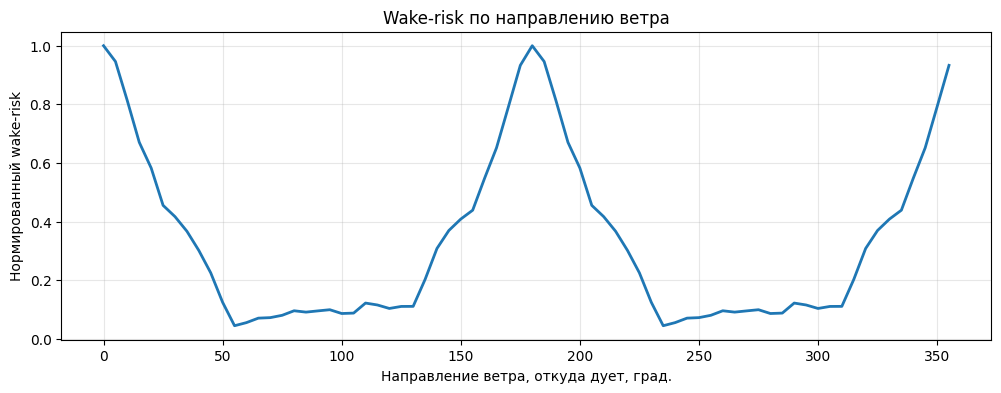

In [195]:
plt.figure(figsize=(12, 4))
plt.plot(wake_table["wind_from_deg"], wake_table["wake_risk_score_norm"], linewidth=2)
plt.title("Wake-risk по направлению ветра")
plt.xlabel("Направление ветра, откуда дует, град.")
plt.ylabel("Нормированный wake-risk")
plt.grid(alpha=0.3)
plt.show()

In [196]:
target_values = pd.to_numeric(df_train["target"], errors="coerce")
repair_values = pd.to_numeric(df_train["turbines_in_repair"], errors="coerce")

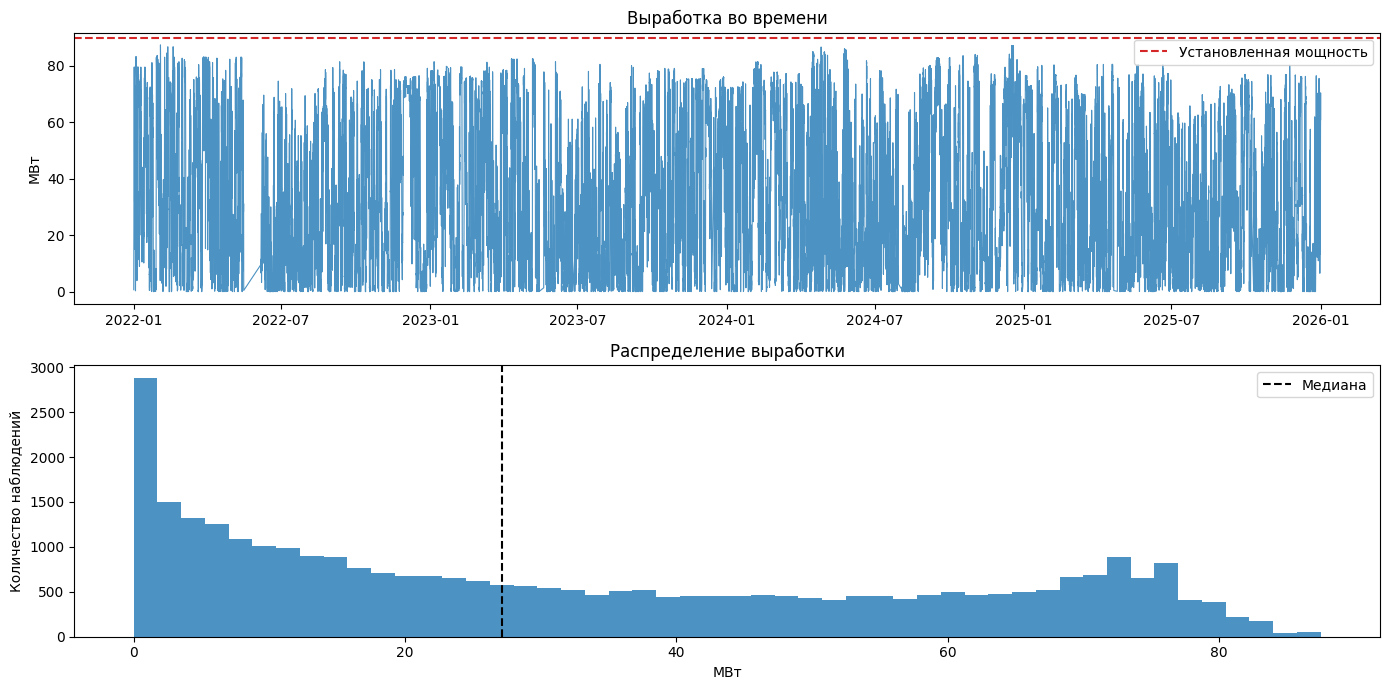

In [197]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(df_train["datetime"], target_values, linewidth=0.8, alpha=0.8)
axes[0].axhline(INSTALLED_CAPACITY_MW, color="tab:red", linestyle="--", label="Установленная мощность")
axes[0].set_title("Выработка во времени")
axes[0].set_ylabel("МВт")
axes[0].legend()

axes[1].hist(target_values.dropna(), bins=50, color="tab:blue", alpha=0.8)
axes[1].axvline(target_values.median(), color="black", linestyle="--", label="Медиана")
axes[1].set_title("Распределение выработки")
axes[1].set_xlabel("МВт")
axes[1].set_ylabel("Количество наблюдений")
axes[1].legend()

plt.tight_layout()
plt.show()

In [198]:
# Погодные источники и временные признаки

weather_difference_cols = [
    "ws10_openm_minus_nasa",
    "ws80_openm_minus_nasa50",
    "pressure_msl_minus_ps",
    "temp80_minus_t2m",
    "wd10_openm_minus_nasa_circular",
]

weather_source_report = df_train[weather_difference_cols].agg(["mean", "std", "median"]).T
weather_source_report["p05"] = df_train[weather_difference_cols].quantile(0.05)
weather_source_report["p95"] = df_train[weather_difference_cols].quantile(0.95)
weather_source_report["missing_share"] = df_train[weather_difference_cols].isna().mean()
weather_source_report

,mean,std,median,p05,p95,missing_share
ws10_openm_minus_nasa,-1.159373,1.418901,-1.17,-3.44,1.20,0.0
ws80_openm_minus_nasa50,-0.513107,1.571829,-0.52,-3.03,2.08,0.0
pressure_msl_minus_ps,914.978653,6.765006,914.33,904.95,926.79,0.0
temp80_minus_t2m,-0.265495,2.198786,-0.16,-4.00,3.21,0.0
wd10_openm_minus_nasa_circular,-11.021638,34.355118,-8.00,-67.60,31.30,0.0


In [199]:
ema_effect_report = ema_effect_df.copy()
ema_effect_report["std_reduction_share"] = 1 - ema_effect_report["smooth_3h_std"] / ema_effect_report["raw_std"]
ema_effect_report

,signal,raw_std,smooth_3h_std,raw_minus_smooth_3h_std,raw_missing_share,std_reduction_share
0,wind_speed_120m_cube,855.775117,828.377601,151.885922,0.0,0.032015
1,p_theory_80,20.510568,19.941938,3.391179,0.0,0.027724
2,p_theory_120,25.284255,24.509977,4.390326,0.0,0.030623
3,wind_power_density_120m,539.023733,522.232764,94.388344,0.0,0.031151


In [200]:
# Качество кривых мощности

curve_quality_rows = []
curve_cols = ["p_theory_120", "p_empirical_120", "p_empirical_iso_120", "p_empirical_mean_80_120"]

for curve_col in curve_cols:
    prediction = pd.to_numeric(df_train[curve_col], errors="coerce").clip(0, INSTALLED_CAPACITY_MW)
    valid_mask = target_values.notna() & prediction.notna()
    curve_quality_rows.append({
        "curve": curve_col,
        "mae": mean_absolute_error(target_values[valid_mask], prediction[valid_mask]),
        "bias": (prediction[valid_mask] - target_values[valid_mask]).mean(),
        "prediction_mean": prediction[valid_mask].mean(),
    })

curve_quality_report = pd.DataFrame(curve_quality_rows).sort_values("mae")
curve_quality_report

,curve,mae,bias,prediction_mean
3,p_empirical_mean_80_120,9.473041,-0.698119,32.307627
2,p_empirical_iso_120,9.702282,-0.603745,32.402001
1,p_empirical_120,9.705588,-0.576407,32.429339
0,p_theory_120,12.154123,-8.305275,24.700471


In [201]:
feature_target_correlation: pd.DataFrame = (
    df_train[model_features]
    .corrwith(df_train["target"])
    .abs()
    .sort_values(ascending=False)
    .head(20)
    .rename("abs_correlation")
    .to_frame()
)

feature_target_correlation

,abs_correlation
p_empirical_mean_80_120,0.863785
p_empirical_iso_mean_80_120,0.863785
p_empirical_iso_120,0.858502
p_empirical_120,0.858498
cf_empirical_iso_120,0.857871
cf_empirical_120,0.857865
p_empirical_iso_80,0.853599
p_empirical_80,0.853593
cf_empirical_iso_80,0.853348
cf_empirical_80,0.853334


In [202]:
FEATURE_EXPORT_DIR = OUT_DIR / "datasets"
FEATURE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

feature_columns = ["datetime", *model_features]

df_train_export = df_train.dropna(subset=["target"])
df_test_export = df_test.dropna(subset=["target"])

df_train_export[feature_columns].to_csv(
    FEATURE_EXPORT_DIR / "train_features.csv", index=False
)

df_train_export[["datetime", "target"]].to_csv(
    FEATURE_EXPORT_DIR / "train_target.csv", index=False
)

df_test_export[feature_columns].to_csv(
    FEATURE_EXPORT_DIR / "test_features.csv", index=False
)

df_test_export[["datetime", "target"]].to_csv(
    FEATURE_EXPORT_DIR / "test_target.csv", index=False
)
